In [6]:
import numpy as np
import matplotlib.pyplot as plt
#import arviz as az
from emcee import autocorr
rng = np.random.default_rng(108)

In [7]:
import sys
print(sys.executable)

/Users/alisenzya/miniconda3/envs/mcmc/bin/python


### Q1

We consider an unknown two-dimensional location
$$
x = (x_1, x_2)^\top \in \mathbb{R}^2.
$$
We use the parametric \emph{banana prior}
$$
p(x_1) = \mathcal{N}(x_1; 0, \sigma_1^2),
$$
$$
p(x_2 \mid x_1) = \mathcal{N}\!\left(x_2;\, b(x_1^2 - \kappa),\, \sigma_2^2\right),
$$
and the one-point range likelihood
$$
p(y \mid x) = \mathcal{N}\!\left(y;\, \lVert x - s \rVert_2^2,\, \sigma_y^2\right).
$$
(where $x = (x_1, x_2) $)

For this coursework, we use
$$
\sigma_1 = 2,\quad
b = 0.25,\quad
\kappa = 4,\quad
\sigma_2 = 0.3,\quad
s = (0,0)^\top,\quad
y = 4.5,\quad
\sigma_y = 0.2.
$$

This is a Bayesian estimation problem, where we are trying to derive the posterior distribution $p(x \mid y)$ which represents our uncertainty of the 2D location given a noisy range measurement y given by the sensor (we assume it is centered at the origin).

Let's derive the target posterior explicitly using Bayes rule (and plugging all the parameters w already set to predefined constants):

$$
\bar{p}_\star(x \mid y) = p(x)p(y \mid x) = p(x_1)p(x_2 \mid x_1) =
$$
$$ 
\mathcal{N}(x_1; 0, \sigma_1^2)\mathcal{N}\!\left(x_2;\, b(x_1^2 - \kappa),\sigma_2^2\right)\mathcal{N}\!\left(y;\, \lVert x - s \rVert_2^2,\, \sigma_y^2\right) = 
$$

$$
\mathcal N(x_1; 0, 4)\;
\mathcal N\!\left(x_2;\, 0.25(x_1^2 - 4),\, 0.09\right)\;
\mathcal N\!\left(4.5;\, x_1^2 + x_2^2,\, 0.04\right) \propto
$$
$$
\propto
\exp\!\left(
-\frac{x_1^2}{2\sigma_1^2}
\right)
\exp\!\left(
-\frac{\left(x_2 - b(x_1^2-\kappa)\right)^2}{2\sigma_2^2}
\right)
\exp\!\left(
-\frac{\left(y - \big[(x_1-s_1)^2 + (x_2-s_2)^2\big]\right)^2}{2\sigma_y^2}
\right)
$$
$$
\exp\!\left(-\frac{x_1^2}{8}\right)
\exp\!\left(
-\frac{\left[x_2 - 0.25(x_1^2 - 4)\right]^2}{0.18}
\right)
\exp\!\left(
-\frac{\left[4.5 - x_1^2 - x_2^2\right]^2}{0.08}
\right).
$$

It is convinient to also have the log-density:

$$
\log(\bar(p)_\star(x \mid y)) =  -\frac{x_1^2}{8}-\frac{\left[x_2 - 0.25(x_1^2 - 4)\right]^2}{0.18}-\frac{\left[4.5 - x_1^2 - x_2^2\right]^2}{0.08}
$$

Below, I implement functions of the prior, likelihood and posterior to plot them. I implement log prior, log likelihood and log posterior for convinience (to later use in MH), and then exponentiate, when needed.

In [8]:
# banana function for testing MCMC
def banana(x1, x2, sigma1=2.0, sigma2=0.3, b=0.25, k=4.0):
    return np.exp(- x1**2 / (2 * sigma1**2) - (x2 - b*(x1**2 - k))**2 / (2 * sigma2**2))


def likelihood(x1, x2, y=4.5, sigma_y=0.2, s=[0.0, 0.0]):
    s1, s2 = s[0], s[1]
    r2 = (x1 - s1)**2 + (x2 - s2)**2
    return np.exp(- (y - r2)**2 / (2 * sigma_y**2))


def posterior(
    x1, x2,
    sigma1=2.0, sigma2=0.3, b=0.25, k=4.0,
    y=4.5, sigma_y=0.2, s=[0.0, 0.0]
):
    return banana(x1, x2, sigma1, sigma2, b, k) * likelihood(x1, x2, y, sigma_y, s)


def log_posterior(x, sigma1=2.0, sigma2=0.3, b=0.25, k=4.0,
    y=4.5, sigma_y=0.2, s=[0.0, 0.0]
):
    x1, x2 = x[0], x[1]
    s1, s2 = s[0], s[1]
    r2 = (x1 - s1)**2 + (x2 - s2)**2
    return - x1**2 / (2 * sigma1**2) - (x2 - b*(x1**2 - k))**2 / (2 * sigma2**2) - (y - r2)**2 / (2 * sigma_y**2)

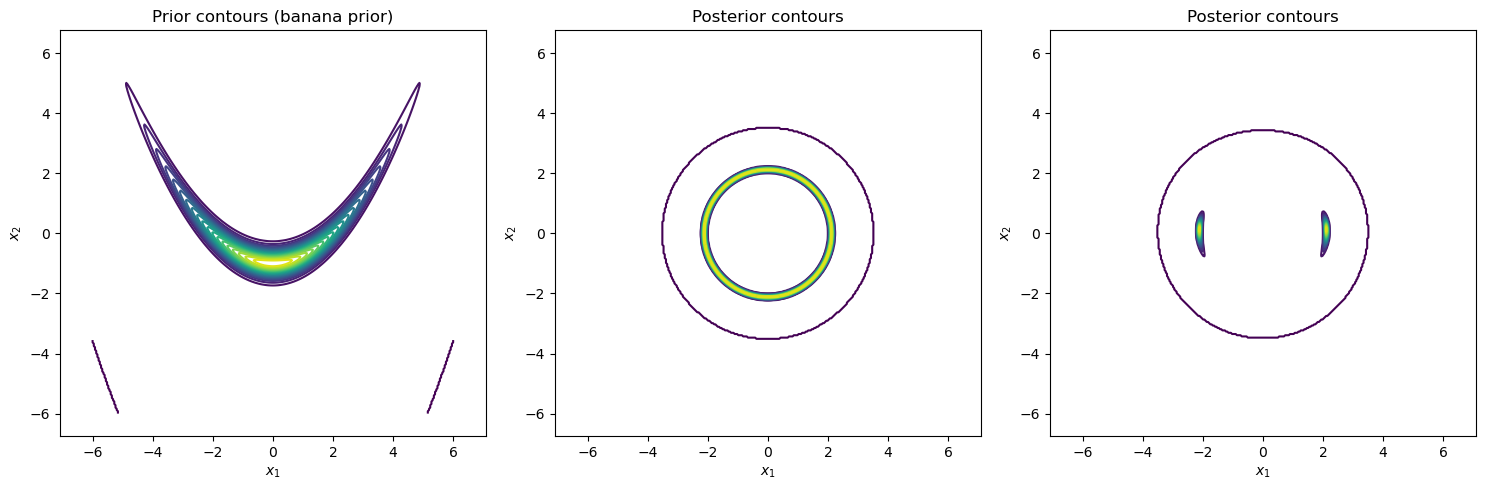

In [9]:
# grid limits

x1_min, x1_max = -6,6
x2_min, x2_max = -6, 6

n = 300  # grid resolution
x1 = np.linspace(x1_min, x1_max, n)
x2 = np.linspace(x2_min, x2_max, n)
X1, X2 = np.meshgrid(x1, x2)

pior = banana(X1, X2)
lhd = likelihood(X1, X2)
post = posterior(X1, X2)

# Plot the countors:

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.contour(X1, X2, pior, levels=20)
plt.title("Prior contours (banana prior)")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")

plt.subplot(1, 3, 2)
plt.contour(X1, X2, lhd, levels=20)
plt.title("Posterior contours")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")

plt.subplot(1, 3, 3)
plt.contour(X1, X2, post, levels=20)
plt.title("Posterior contours")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.axis("equal")

plt.tight_layout()
plt.show()



In [10]:
# Just out of curiocity
# let's also plot the countours of log prior, likelihood and posterior:

### 1(b): Deriving $\nabla_x \log(p(x \mid y))$

$$
\nabla_x \log \bar p(x_1,x_2 \mid y)
=
\begin{pmatrix}
\displaystyle \frac{\partial}{\partial x_1} \log \bar p(x_1,x_2 \mid y) \\
\displaystyle \frac{\partial}{\partial x_2} \log \bar p(x_1,x_2 \mid y)
\end{pmatrix}.
$$

$$
\frac{\partial}{\partial x_1} \log \bar p(x_1,x_2 \mid y)
=
-\frac{2x_1}{8}
+
\frac{0.25 \cdot 2x_1}{0.18} \cdot
2 \left[x_2 - 0.25(x_1^2 - 4)\right]
+
2 \cdot \frac{4.5 - (x_1^2 + x_2^2)}{0.08} \cdot 2x_1.
$$

$$
\frac{\partial}{\partial x_2} \log \bar p(x_1,x_2 \mid y)
=
0 -\frac{2}{0.18}
\left[x_2 - 0.25(x_1^2 - 4)\right]
+
2 \cdot \frac{4.5 - (x_1^2 + x_2^2)}{0.08} \cdot 2x_2.
$$

Simplifying the coefficients leeds to:

$$
\nabla_x \log \bar p(x_1,x_2 \mid y)
=
\begin{pmatrix}
-\dfrac{x_1}{4}
+ \dfrac{x_1}{0.18}\left[x_2 - 0.25(x_1^2 - 4)\right]
+ 50 x_1 \left[4.5 - (x_1^2 + x_2^2)\right]
\\[10pt]
-\dfrac{1}{0.09}\left[x_2 - 0.25(x_1^2 - 4)\right]
+ 50 x_2 \left[4.5 - (x_1^2 + x_2^2)\right]
\end{pmatrix}.
$$

### 1(c): Random Walk Metropolis-Hastings

Our aim is to extimate location, so our target density is $p(x_1, x_2 \mid y)$.

In this part, we will implement a Random Walk Metropolis Hastings sampler.

The algorithm constructs a Markov Chain, whose limiting distribution is an approximation of the target density. Starting at the current state $X$, the algorithm proposes a new state $X' = X + \epsilon$ with $\epsilon ~ \mathcal N (0; \sigma^2I) (a random walk step), accepting or rejecting $X'$ based on an acceptance rule. In general, MH algorithm proposes $X' ~ q(X' \mid X)$ and the acceptance rule is 
$$
\alpha(X_{n-1}, X') 
= \min \left\{ 
1,\;
\frac{p_\star(X')\, q(X_{n-1} \mid X')}
     {p_\star(X_{n-1})\, q(X' \mid X_{n-1})}
     \right\}
$$

However, since our random walk proposal $q(x \mid x') = \mathcal{N}(x; x', \sigma_q I)$ is symmetric, the acceptance rule simplifies to $\frac{p_\star(X')}{p_\star(X_{n-1})}$. This is easy to interpret: is the algorithm moves into a region of higher density, it is automatically accepted, and if it moves to a lowe-density region, it is accepted with probability proportional to how low the densiy is.

Here is the pseudocode for the RWMH Algo:

$$
\textbf{Algorithm 9: Metropolis–Hastings Method}
$$

$$
\begin{aligned}
1.\;& \textbf{Input: } \text{number of samples } N \text{ and starting point } X_0. \\[6pt]
2.\;& \textbf{for } n = 1, \dots, N \textbf{ do} \\[6pt]
3.\;& \quad \text{Propose: } X' \sim q(x' \mid X_{n-1}) \\[6pt]
4.\;& \quad \text{Accept } X' \text{ with probability} \\[6pt]
& \quad \alpha(X_{n-1}, X') 
= \min \left\{ 
1,\;
\frac{p_\star(X')\, q(X_{n-1} \mid X')}
     {p_\star(X_{n-1})\, q(X' \mid X_{n-1})}
\right\} \\[10pt]
5.\;& \quad \text{Otherwise reject and set } X_n = X_{n-1}. \\[6pt]
6.\;& \textbf{end for} \\[6pt]
7.\;& \text{Discard first burn-in samples and return the remaining samples.}
\end{aligned}
$$


We will try to tune $\sigma_q$ using ESS and acceptance rate.

In [11]:
def proposal(x, sigma):
    return x + sigma * np.random.randn(2)

def rwmh(target=log_posterior, N=10**6, x0=np.array([0,0]), sigma1=1.5, sigma2=0.15, burnin=1000):

    samples_RW = np.zeros((N, 2))
    samples_RW[0] = x0
    
    # for acceptance ratio
    acc_count = 0

    for n in range(1, N):

        # random walk
        x_prev = samples_RW[n-1]
        x_dash = x_prev + np.array([sigma1, sigma2]) * rng.standard_normal(2)
        # metropolis
        u = rng.uniform(0, 1)
        alpha = target(x_dash) - target(x_prev)

        if np.log(u) < alpha:
            samples_RW[n] = x_dash
            acc_count += 1
        else:
            samples_RW[n] = x_prev
    acc = acc_count / (N-1)
    return samples_RW[burnin:], acc

mc, acc = rwmh(log_posterior, N=500000)
print(acc)

0.038348076696153394


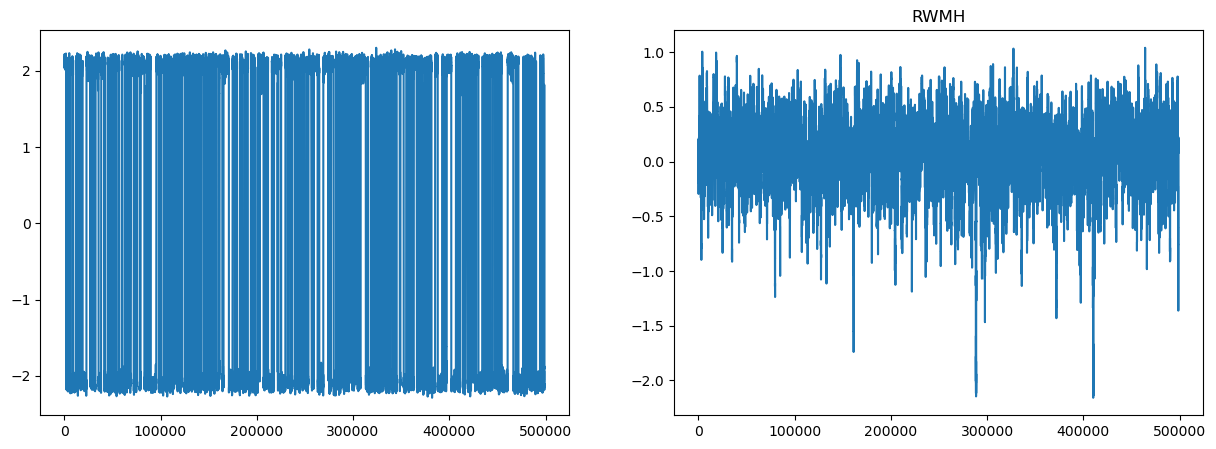

In [12]:
# Trace plots for both coordinates
def trace_plots(sample, title):
    trace1 = sample[:, 0]
    trace2 = sample[:, 1]
    x = np.arange(0, len(trace1))

    plt.figure(figsize=(15,5))

    plt.subplot(1, 2, 1)
    plt.plot(x, trace1)
    plt.title("")

    plt.subplot(1, 2, 2)
    plt.plot(x, trace2)
    plt.title(title)

trace_plots(mc, "RWMH")

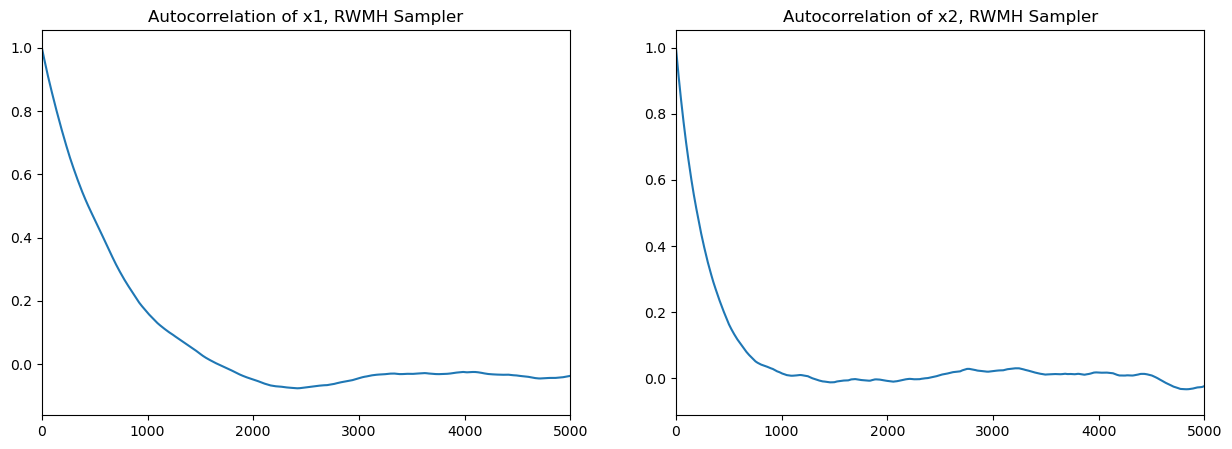

In [13]:
# Autocorrelation plots

def autocorr_plots(sample, title):
    ro_x1 = autocorr.function_1d(sample[:, 0])
    x1 = np.arange(0, len(ro_x1))
    ro_x2 = autocorr.function_1d(sample[:, 1])
    x2 = np.arange(0, len(ro_x2))

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x1, ro_x1)
    plt.xlim(0,5000)
    plt.title("Autocorrelation of x1, " + title)

    plt.subplot(1, 2, 2)
    plt.plot(x2, ro_x2)
    plt.xlim(0,5000)
    plt.title("Autocorrelation of x2, " + title)

autocorr_plots(mc, "RWMH Sampler")

In [14]:
sigmas = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0]
best_ess = -np.inf
for s in sigmas:
    samples, acc = rwmh(
        N=80_000,
        sigma_q = s
    )
    # emcee intergrated time needs 3d array
    chain = samples[:, None, :]
    tau = autocorr.integrated_time(chain, quiet=True)
    ess = samples.shape[0] / tau
    ess_min = float(np.min(ess))

    print(f"sigma={s}, acc={acc:.3f}, minESS={ess_min:.0f}")

    if ess_min > best_ess:
        best_ess = ess_min
        best_sigma = s
print(best_sigma)

TypeError: rwmh() got an unexpected keyword argument 'sigma_q'

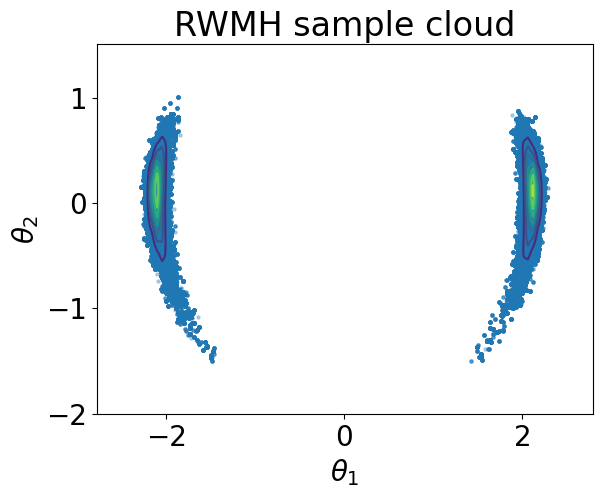

In [385]:
def samples_cloud(samples, title):
    # grid covering the sample range
    x = samples[:, 0]
    y = samples[:, 1]

    xs = np.linspace(x.min() - 0.5, x.max() + 0.5, 100)
    ys = np.linspace(y.min() - 0.5, y.max() + 0.5, 100)
    X, Y = np.meshgrid(xs, ys)

    # evaluate posterior on grid
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = posterior(X[i, j], Y[i, j])

    # contour of log posterior (unnormalised)
    plt.contour(X, Y, Z)

    # sample cloud
    plt.scatter(x, y, s=5, alpha=0.3)

    plt.xlabel(r"$\theta_1$")
    plt.ylabel(r"$\theta_2$")
    plt.title(title)
    plt.show()

samples_cloud(mc, "RWMH sample cloud")

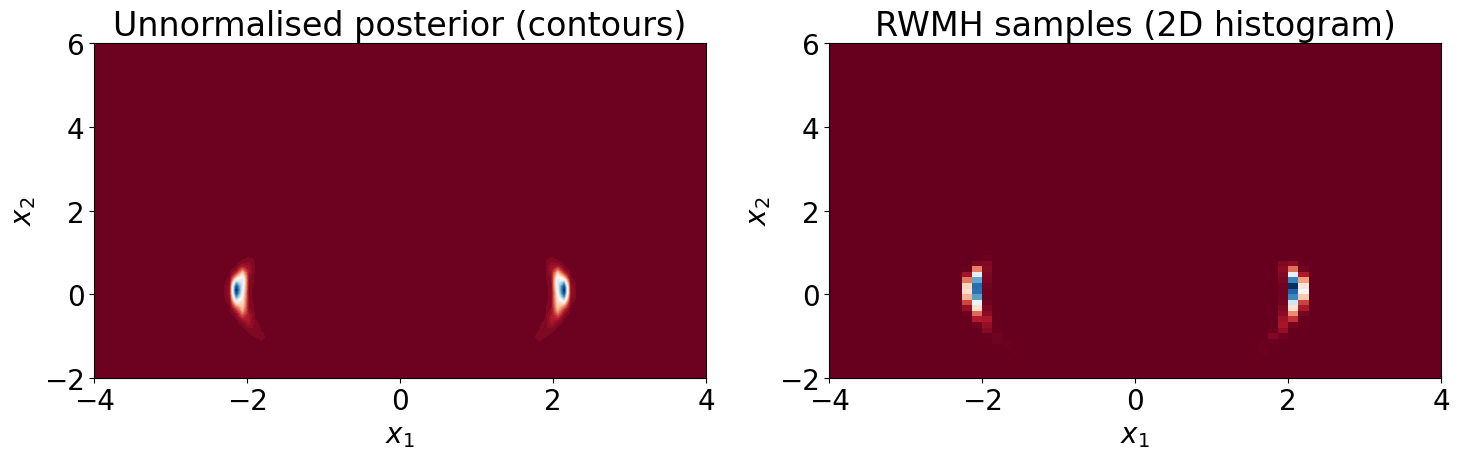

In [ ]:

# for surf plot posterior 2d
x_bb = np.linspace(-4, 4, 100)
y_bb = np.linspace(-2, 6, 100)
X_bb, Y_bb = np.meshgrid(x_bb, y_bb)
Z_bb = np.exp(posterior(X_bb, Y_bb))

plt.figure(figsize=(15, 5))
plt.rcParams.update({'font.size': 20})

# Left: unnormalised posterior contour
plt.subplot(1, 2, 1)
plt.contourf(X_bb, Y_bb, Z_bb, levels=60, cmap='RdBu')
plt.xlim(-4, 4); plt.ylim(-2, 6)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("Unnormalised posterior (contours)")

# Right: 2D histogram of samples
plt.subplot(1, 2, 2)
plt.hist2d(
    mc[:, 0], mc[:, 1],
    bins=60,
    range=[[-4, 4], [-2, 6]],
    density=True,
    cmap='RdBu'
)

plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("RWMH samples (2D histogram)")

plt.tight_layout()
plt.show()

### 1d: Metropolis-adjusted Langevin algorithm (MALA)

The main difference between MALA and RWMH is the proposal: for MALA, we inform the proposal by using the gradient of the target distribution:

$$
q(x' \mid x) = \mathcal{N}\!\left(x' \,;\, x + \gamma \nabla \log p_{\star}(x), \, 2\gamma I \right)
$$

As always, using logs significantly simplifies calculations, so let us first derive $\log(q(x' \mid x))$:

$$
\log q(x)
=
-\frac12 (x-\mu)^T \Sigma^{-1} (x-\mu)
-\frac12 \log |\Sigma|
-\frac d2 \log(2\pi).
$$

$$
(x-\mu)^T \Sigma^{-1} (x-\mu)
=
\frac{1}{2\gamma}\|x-\mu\|^2.
$$
$$
\log q(x' \mid x)
=
-\frac{\|x' - \mu(x)\|^2}{4\gamma}
+ C,
$$

where \(C\) is a constant independent of \(x\), so we drop it.

In [ ]:
def grad_log_posterior(x,
    sigma1=2.0, sigma2=0.3,
    b=0.25, kappa=4.0,
    y=4.5, sigma_y=0.2,
    s=[0.0, 0.0]
):
    x1, x2 = x[0], x[1]
    s1, s2 = s[0], s[1]

    # helper terms
    u = x2 - b * (x1**2 - kappa)
    r = y - ((x1 - s1)**2 + (x2 - s2)**2)

    d1 = (
        -(x1 / (sigma1**2))
        + (2.0 * b * x1 / (sigma2**2)) * u
        + (2.0 * (x1 - s1) / (sigma_y**2)) * r
    )

    d2 = (
        -(1.0 / (sigma2**2)) * u
        + (2.0 * (x2 - s2) / (sigma_y**2)) * r
    )

    return np.stack([d1, d2], axis=-1) # for the shape to be (N, 2)

# Check that it works corectly
grad_log_posterior([0,1])

array([  0.        , 152.77777778])

In [375]:
def mala(target=log_posterior, N=500_000, x0=np.array([0,0]), gamma=0.0035, burnin=5000):

    samples = np.zeros((N, 2))
    samples[0] = x0
    
    # for acceptance ratio
    acc_count = 0

    def log_q(x_to, x_from):
        mean = x_from + gamma * grad_log_posterior(x_from)
        diff = x_to - mean
        return - np.dot(diff, diff) / (4 * gamma)

    for n in range(1, N):

        # proposal step
        x_prev = samples[n-1]
        mean = x_prev + gamma * grad_log_posterior(x_prev)
        x_dash = mean + np.sqrt(2 * gamma) * np.random.randn(2)
        # metropolis
        u = rng.uniform(0, 1)
        log_alpha = (
            target(x_dash)
            - target(x_prev)
            + log_q(x_prev, x_dash)
            - log_q(x_dash, x_prev)
        )

        if np.log(u) < log_alpha:
            samples[n] = x_dash
            acc_count += 1
        else:
            samples[n] = x_prev
    # calculate acceptance
    acc = acc_count / (N-1)
    return samples[burnin:], acc

mala_mc, acc = mala()


7.4000148000296e-05


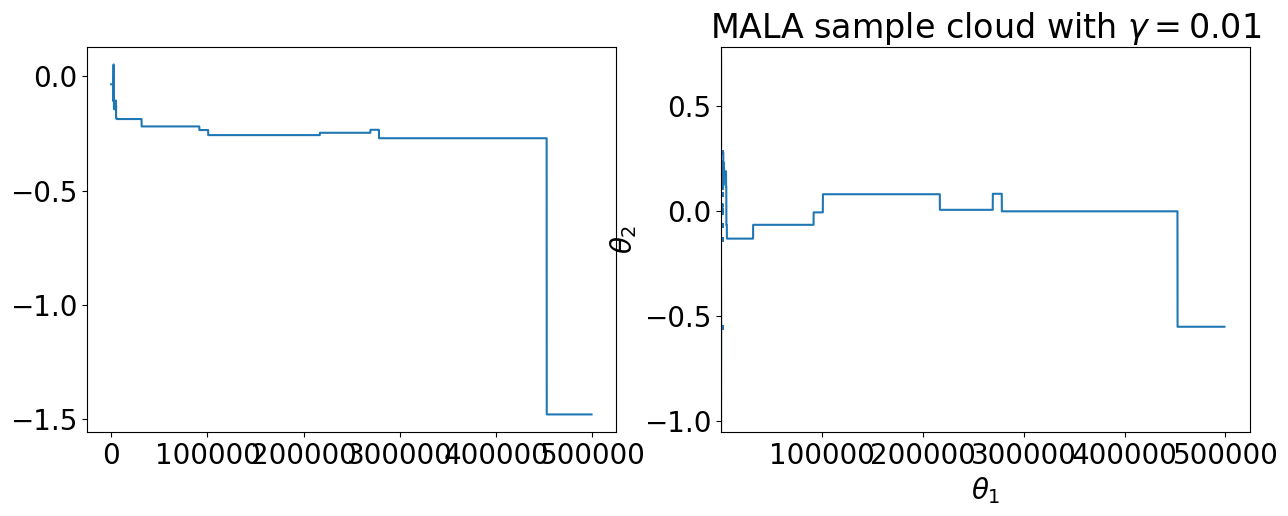

0.415246830493661


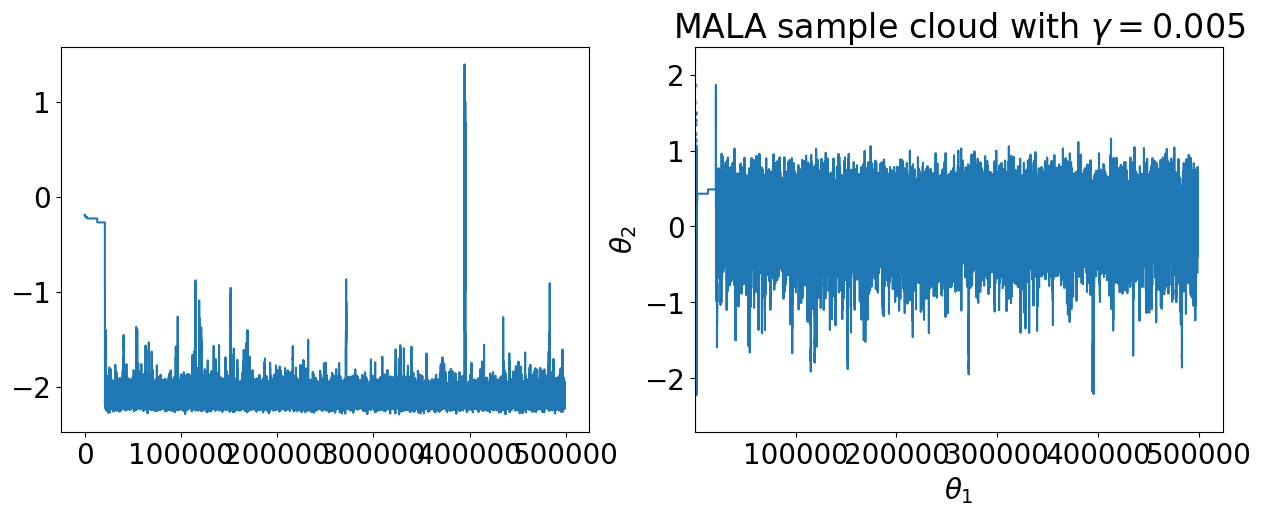

0.9301318602637205


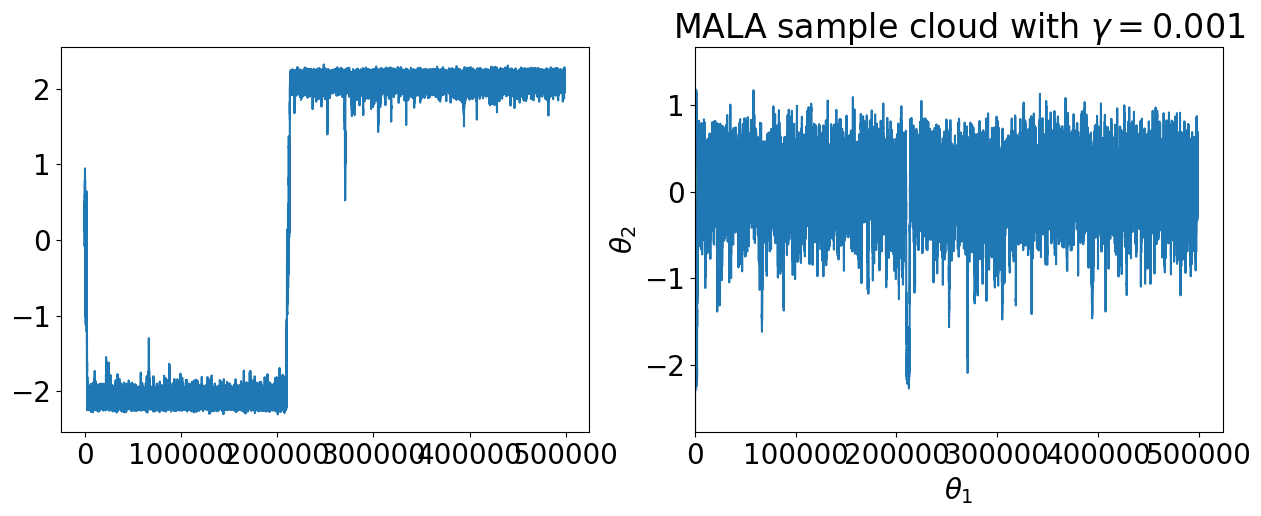

0.9750299500599001


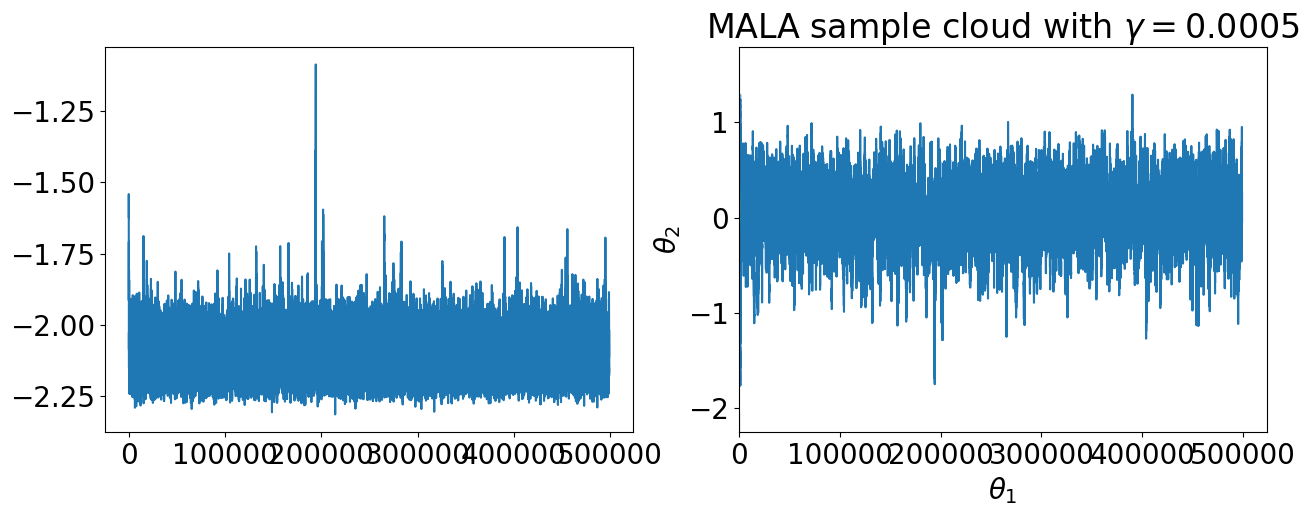

0.9977879955759912


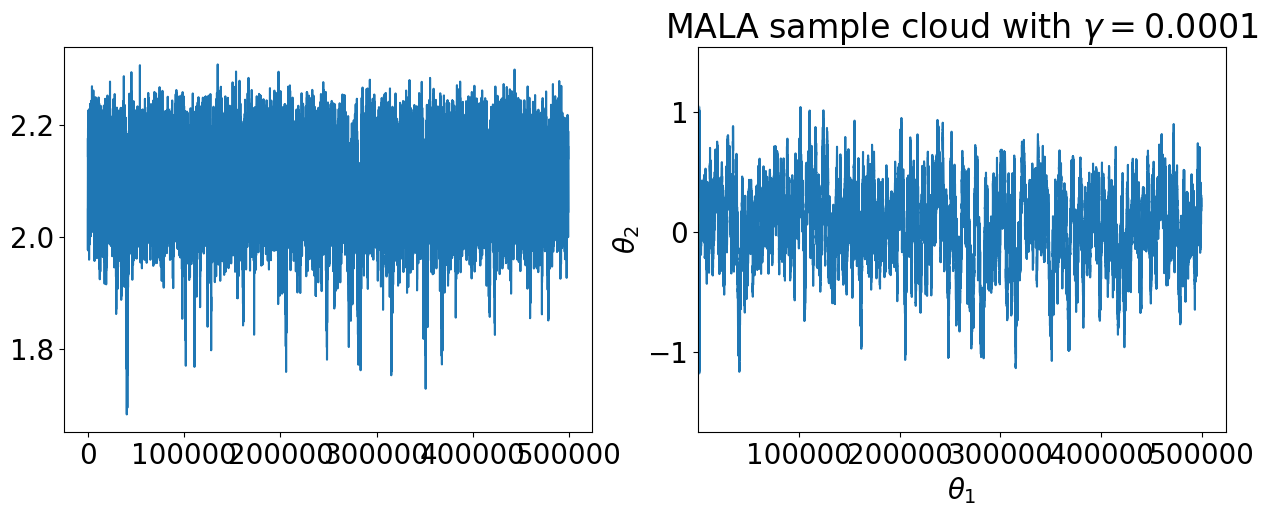

In [393]:
gamma_list = [0.01, 0.005, 0.001, 0.0005, 0.0001]
for gamma in gamma_list:
    mala_g, acc = mala(N=500_000, gamma=gamma, burnin = 1000)
    print(acc)
    trace_plots(mala_g, f"MALA traceplots with $\gamma = ${gamma}")
    samples_cloud(mala_g, f"MALA sample cloud with $\gamma = ${gamma}")

0.5760851521703043


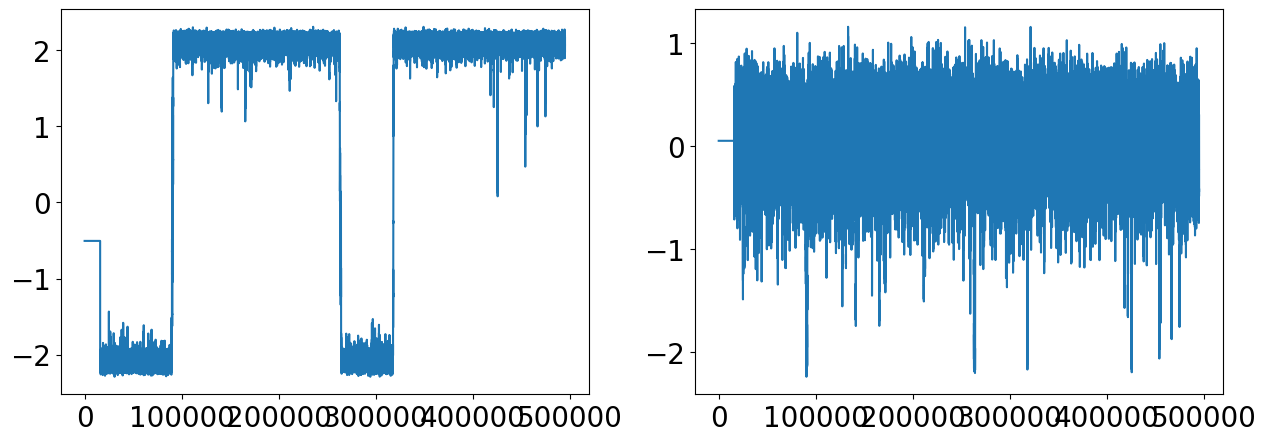

In [376]:
trace_plots(mala_mc, "RWMH")
print(acc)

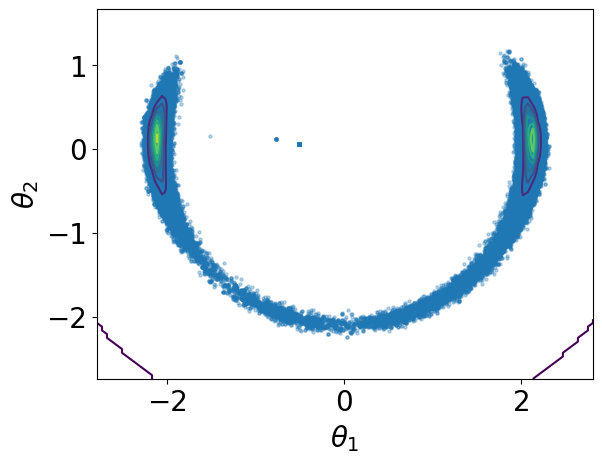

In [377]:
samples_cloud(mala_mc)

### 1e: Unadjusted Langevin Algorithm
This is one example from a family of Langevin MCMC algorithms, which all rely on the following SDE:
$$
dX_t = \nabla \log p_\star(X_t)\, dt + \sqrt{2}\, dB_t
$$

As it turns out, the marginal distribution of $X_t$ converges to $p_\star$. 

The SDE can be discretised as follows:

$$
X_n = X_{n-1} + \gamma \nabla \log p_\star(X_{n-1}) + \sqrt{2\gamma}\, W_n
$$
Which is equivalent to the proposal we used in part 1d for MALA:

$$
q(x_n \mid x_{n-1}) = \mathcal{N}\left(x_n;\, x_{n-1} + \gamma \nabla \log p_\star(x_{n-1}),\, 2\gamma I_d \right)
$$
One caveat is that the discretisation of the SDE would incur bias, which is why MALA is "Metropolised". However, the Metropolis step can be computationally infeasible in higher dimensions. Which is why, in Unadjusted Langevin algorithm, we drop the Metropolis step. Under various conditions, it can be shown that the limiting distribution of ULA $p_\star^\gamma$ can be made arbitrarily close to $p_\star$ as $\gamma \rightarrow 0$.




In [ ]:
def ula(target=log_posterior, N=1_000_000, 
        x0=np.array([0,0]), gamma=0.001, burnin=7000):

    samples = np.zeros((N, 2))
    samples[0] = x0

    for n in range(1, N):

        # proposal step
        x_prev = samples[n-1]
        mean = x_prev + gamma * grad_log_posterior(x_prev)
        x_next = mean + np.sqrt(2 * gamma) * np.random.randn(2)
        samples[n] = x_next
    return samples[burnin:]

ula_mc = ula()


/var/folders/z9/c4qhll5j4d1_vdj8tbv7xnfw0000gn/T/ipykernel_36146/2360833716.py:11: RuntimeWarning: overflow encountered in scalar power
  u = x2 - b * (x1**2 - kappa)
/var/folders/z9/c4qhll5j4d1_vdj8tbv7xnfw0000gn/T/ipykernel_36146/2360833716.py:12: RuntimeWarning: overflow encountered in scalar power
  r = y - ((x1 - s1)**2 + (x2 - s2)**2)
/var/folders/z9/c4qhll5j4d1_vdj8tbv7xnfw0000gn/T/ipykernel_36146/2360833716.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  u = x2 - b * (x1**2 - kappa)


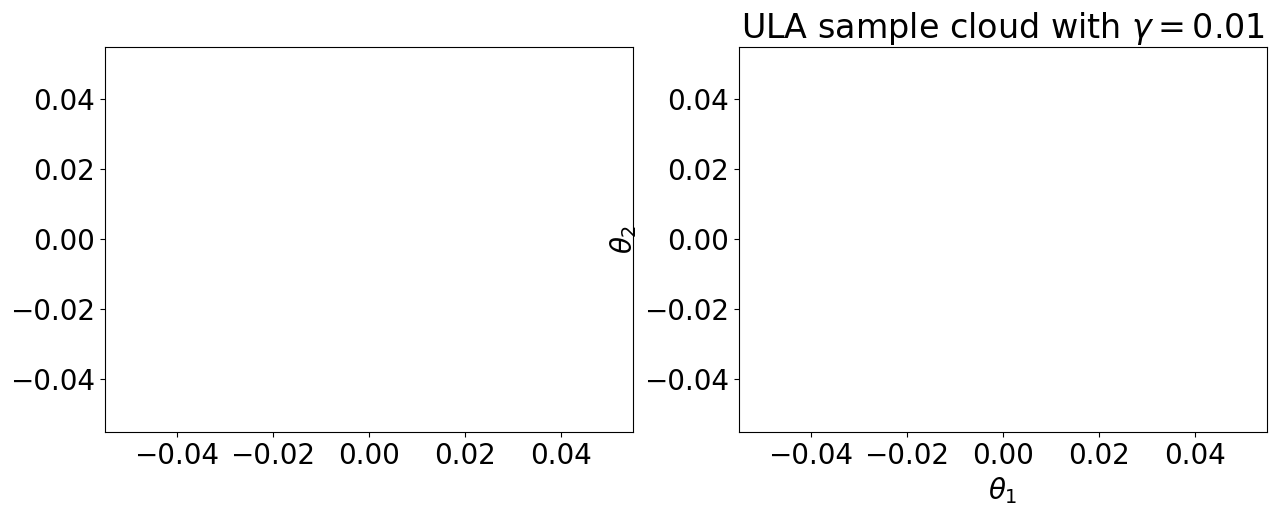

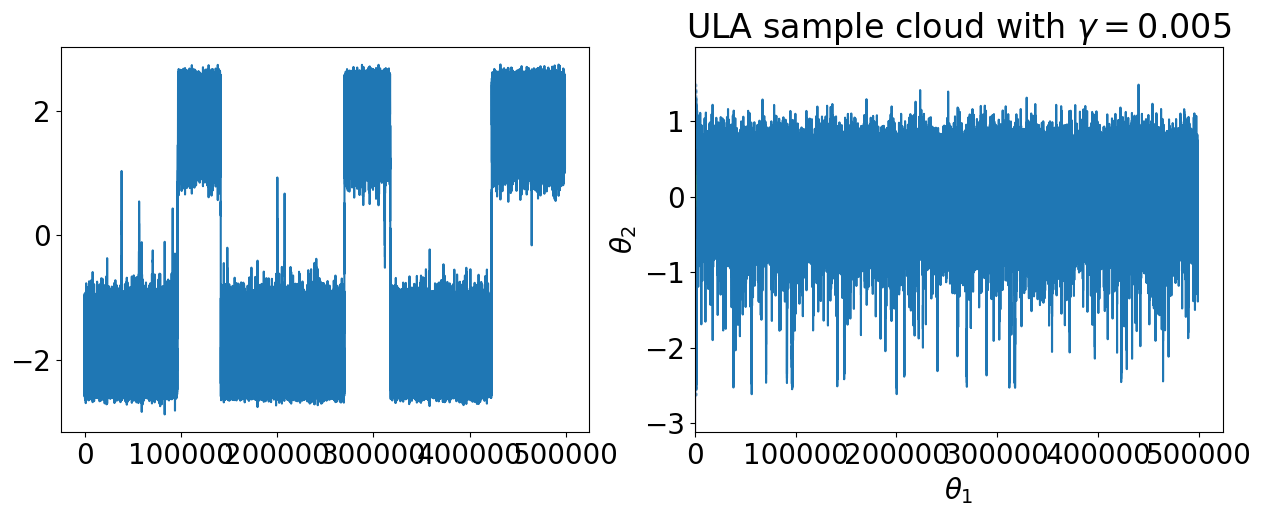

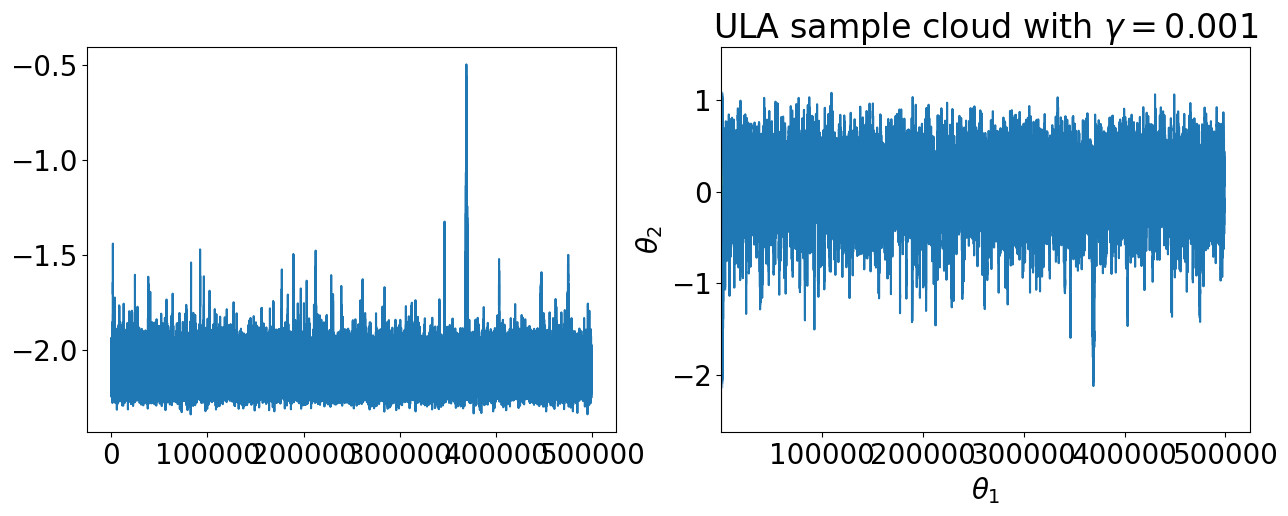

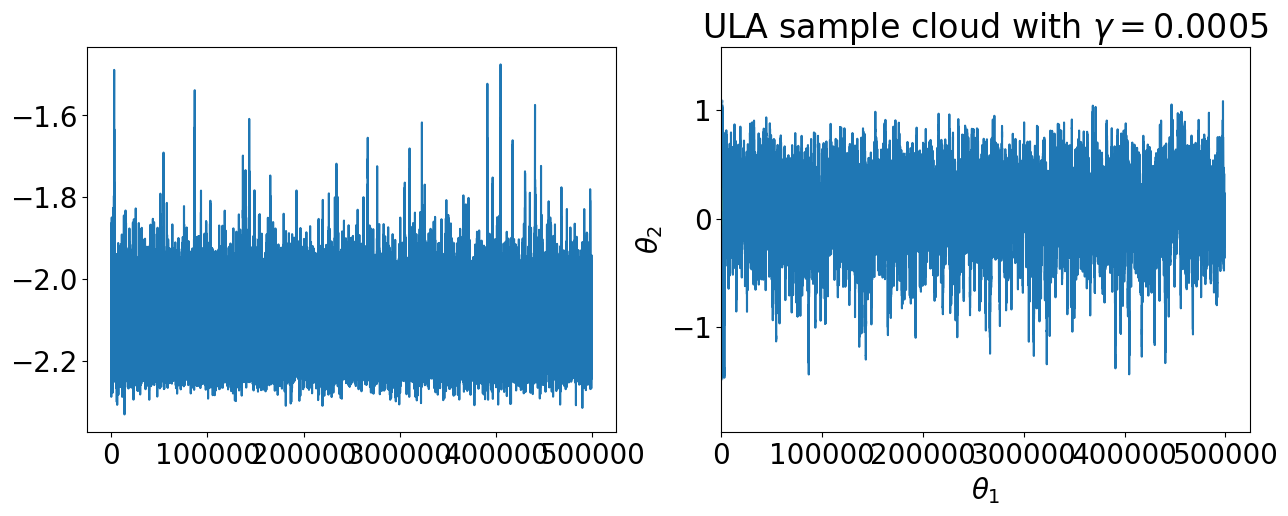

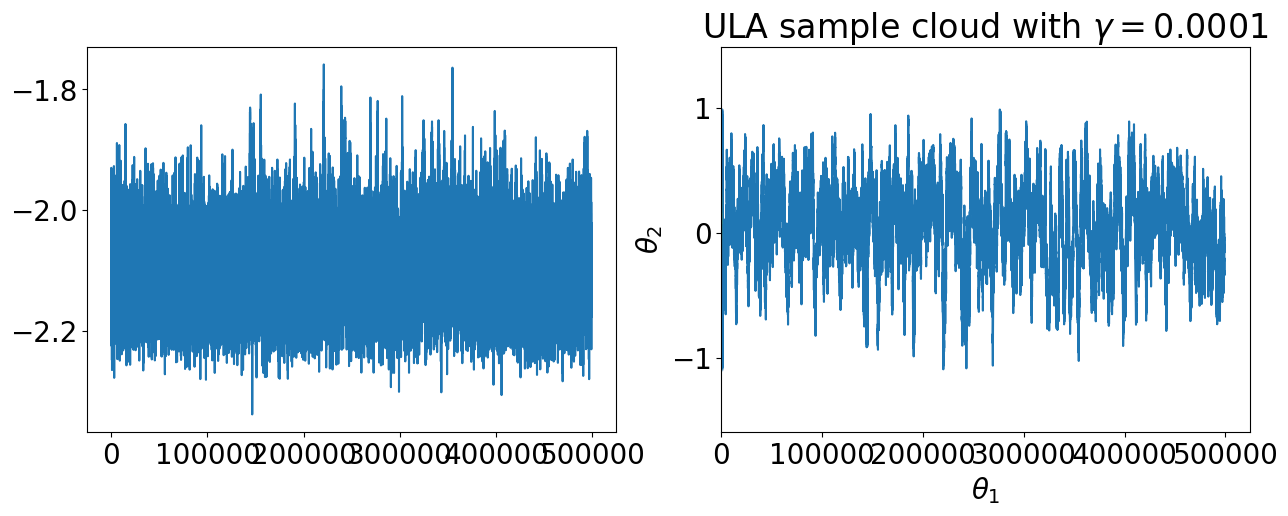

In [386]:
# Tuning gamma by looking at the sample cloud

gamma_list = [0.01, 0.005, 0.001, 0.0005, 0.0001]
for gamma in gamma_list:
    ula_g = ula(N=500_000, gamma=gamma, burnin = 1000)
    trace_plots(ula_g, f"ULA traceplots with $\gamma = ${gamma}")
    samples_cloud(ula_g, f"ULA sample cloud with $\gamma = ${gamma}")

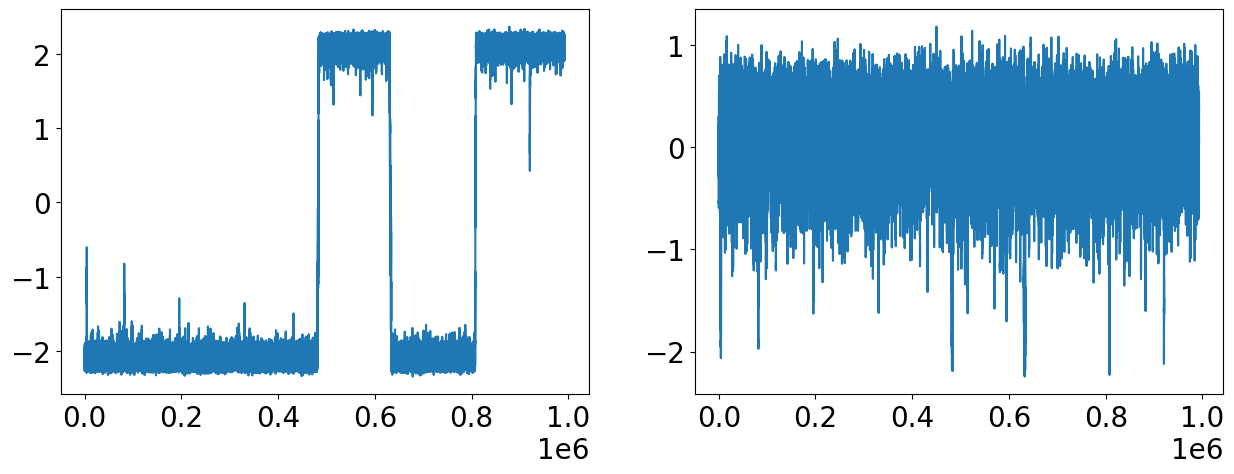

In [340]:
trace_plots(ula_mc, "RWMH")

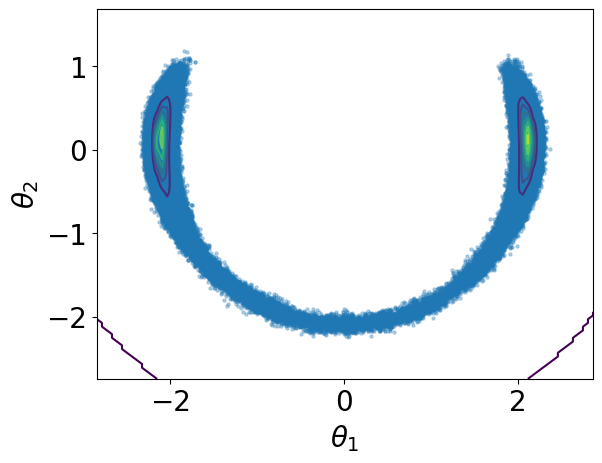

In [341]:
samples_cloud(ula_mc)